# Assignment 3: Using Compilation Techniques and GPUs for Optimization
Group 15

- NG, Cheuk Nam (cnng@kth.se)
- WONG, Chun Him (chwon@kth.se)

## Dependencies

In [10]:
!pip install line_profiler
!pip install memory_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.5 MB/s eta 0:00:00


## Extensions

In [11]:
%load_ext line_profiler
%load_ext memory_profiler

## Imports

In [3]:
import time
import random
import statistics
import matplotlib.pyplot as plt

# Exercise 1: Gauss-Seidel for Poisson Solver

## Task 1.1: Develop the Gauss-Seidel solver with Python List, array, or NumPy

### Implmentation with Python List

In [2]:
def gauss_seidel_list(f, N):
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
    return f

### Profiling

#### Grid Initialiser

In [7]:
def initialise_grid(N):
    grid = [[random.random() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        grid[i][0] = grid[i][N-1] = 0
        grid[0][i] = grid[N-1][i] = 0
    return grid

In [15]:
def initialise_and_run(N, iterations):
    f = initialise_grid(N)
    for _ in range(iterations):
        f = gauss_seidel_list(f, N)
    return f

In [22]:
def run_only(f, N, iterations):
    for _ in range(iterations):
        f = gauss_seidel_list(f, N)
    return f

#### Profiling for Execution Time

In [29]:
def profile_time(run_only_func, init_func, grid_sizes,
                          iterations=1000, runs_per_size=10, title="Python Lists"):
    means = []
    stds = []

    print(f"Starting profiling: {iterations} iterations per run, {runs_per_size} runs per size.")

    for N in grid_sizes:
        run_times = []
        print(f"Grid {N}x{N}: Running {runs_per_size} samples", end=" ", flush=True)

        for _ in range(runs_per_size):
            f = init_func(N)

            start_time = time.perf_counter()
            f = run_only_func(f, N, iterations)
            end_time = time.perf_counter()

            run_times.append(end_time - start_time)

        avg = statistics.mean(run_times)
        sd = statistics.stdev(run_times) if len(run_times) > 1 else 0
        means.append(avg)
        stds.append(sd)
        print(f"Avg: {avg:.4f}s")

    plt.figure(figsize=(10, 6))
    plt.errorbar(grid_sizes, means, yerr=stds, fmt='-o', capsize=5,
                 linewidth=2, markersize=8, color='#2c3e50', ecolor='#e74c3c',
                 label=f'{title} ({iterations} iterations)')

    plt.title(f'Performance Profile: {title}', fontsize=14)
    plt.xlabel('Grid Size ($N \times N$)', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)

    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return means, stds

In [ ]:
grid_sizes = range(50, 550, 50)
iterations = 1000
runs_per_size = 10

profile_time(run_only, initialise_grid, grid_sizes, iterations, runs_per_size)

From the above results we can see that the execution time increases quadratically as we have a nested for loop inside.

## Task 1.2: Profile the code to identify the part of the code to optimise

### Methods and Tools

- %prun: a magic command that provides the same functionality as the cProfile module.
- %lprun: a magic command that provides line-by-line profiling of functions.
- %mprun: a magic command that provides memory profiling of functions.

### Conditions

- Grid size: 100
- Gauss-Seidel Iterations: 1000
- Runs per size: 1

> cProfile is skipped as we only have a single function for this scenario.

### Line-by-line Profiling `gauss_seidel_list`

In [16]:
%lprun -f gauss_seidel_list initialise_and_run(100, 1000)

```
Timer unit: 1e-09 s

Total time: 8.93418 s

gauss_seidel_list

Line #      Hits         Time  Per Hit   % Time
==============================================================
     1                                           
     2     99000   37448558.0    378.3      0.4  
     3   9702000 3578991651.0    368.9     40.1  
     4   9604000 5313929994.0    553.3     59.5  
     5      1000    3808819.0   3808.8      0.0
```

From the line_profile results, we can see that the arithmetic operation on line 4 of the function `f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])` unsuprisingly takes most of the execution time. Optimisation could be prioritised to speed up the operation on list cells.

## Task 1.3: Use the Cython Annotation tool to identify the parts to use Cython

### Creating the .pyx File

In [17]:
%%writefile gauss_seidel_cy.pyx

def gauss_seidel_list(f, N):
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
    return f

Writing gauss_seidel_cy.pyx


### Analysing the .pyx File with Cython

In [36]:
!cython -a gauss_seidel_cy.pyx

/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/gauss_seidel_cy.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)


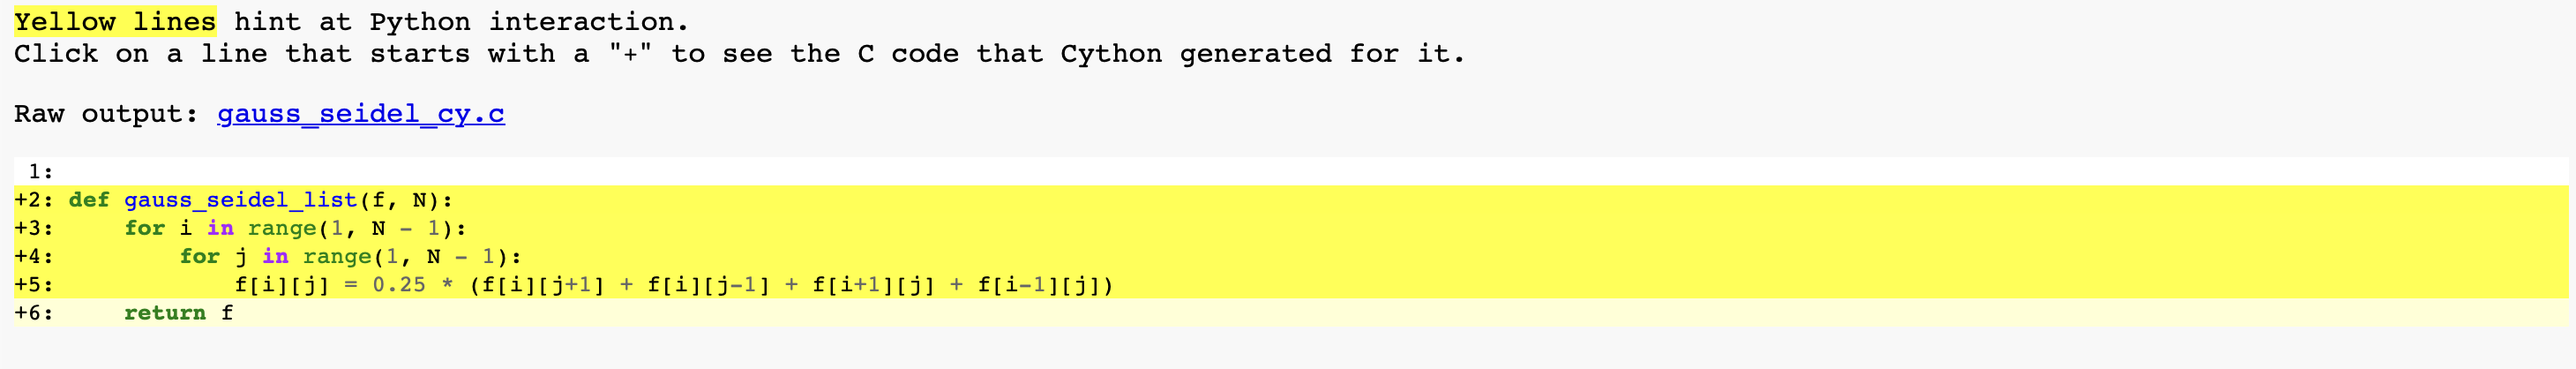

We can see that except line 6, all other lines has a high intensity of yellow background, that means they all make a lot of callbacks to the Python Virtual Machine, we should declare the types of most of the objects in this function.

## Task 1.4: Use Cython to optimise the part you identified as the most computationally expensive

### Creating the .pyx file with types

In [57]:
%%writefile gauss_seidel_cy_typed.pyx

#cython: boundscheck=False
def gauss_seidel_list(f: list, unsigned int N):
    cdef unsigned int i, j
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
    return f

Overwriting gauss_seidel_cy_typed.pyx


### Creating setup_typed.py

In [58]:
%%writefile setup_typed.py
from distutils.core import setup
from Cython.Build import cythonize

setup(ext_modules = cythonize("gauss_seidel_cy_typed.pyx", compiler_directives={"language_level": "3"}))

Overwriting setup_typed.py


### Analysing the typed .pyx File with Cython

In [59]:
!cython -a gauss_seidel_cy_typed.pyx

/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/gauss_seidel_cy_typed.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)


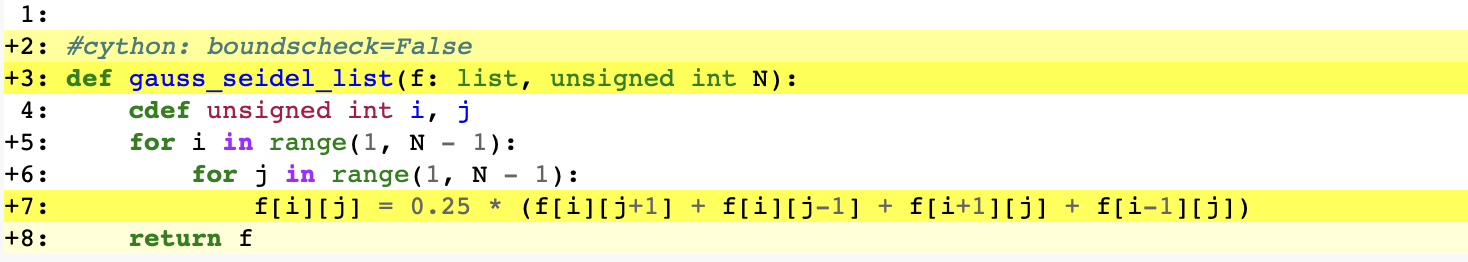

We can see that now for the for-loop lines are turned white after the type annotations.

### Calling the Typed Cythonised Code

In [50]:
!python setup_typed.py build_ext --inplace

In [52]:
import gauss_seidel_cy_typed
def run_only_cythonised_typed(f, N, iterations):
    for _ in range(iterations):
        f = gauss_seidel_cy_typed.gauss_seidel_list(f, N)
    return f

### Profiling the Execution Time

In [53]:
grid_sizes = range(50, 550, 50)
iterations = 1000
runs_per_size = 10

profile_time(run_only_cythonised_typed, initialise_grid, grid_sizes, iterations, runs_per_size)

Starting profiling: 1000 iterations per run, 10 runs per size.
Grid 50x50: Running 10 samples Avg: 0.2138s
Grid 100x100: Running 10 samples Avg: 1.0723s
Grid 150x150: Running 10 samples Avg: 2.6238s
Grid 200x200: Running 10 samples Avg: 5.0456s
Grid 250x250: Running 10 samples Avg: 6.9961s
Grid 300x300: Running 10 samples Avg: 10.3983s
Grid 350x350: Running 10 samples Avg: 14.1962s
Grid 400x400: Running 10 samples 

KeyboardInterrupt: 

When comparing this to the profiling of the non-Cython code, it's evident that the graph's gradient is significantly less, demonstrating a computational time that is much more linear. The improvements are measurable in seconds.

## Task 1.5 Use PyTorch to port your code to Nvidia GPUs

###

# Bonus Task
Mandelbrot Set

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def mandelbrot(c, max_iter=100):
    """Computes the number of iterations before divergence."""
    z = 0
    for n in range(max_iter):
        if abs(z) > 2:
            return n
        z = z*z + c
    return max_iter

def mandelbrot_set(width, height, x_min, x_max, y_min, y_max, max_iter=100):
    """Generates the Mandelbrot set image."""
    x_vals = np.linspace(x_min, x_max, width)
    y_vals = np.linspace(y_min, y_max, height)
    image = np.zeros((height, width))

    for i in range(height):
        for j in range(width):
            c = complex(x_vals[j], y_vals[i])
            image[i, j] = mandelbrot(c, max_iter)

    return image

# Parameters
width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1

# Generate fractal
image = mandelbrot_set(width, height, x_min, x_max, y_min, y_max)

# Display
plt.imshow(image, cmap='inferno', extent=[x_min, x_max, y_min, y_max])
plt.colorbar()
plt.title("Mandelbrot Set")
plt.show()


## Task B.1
### Cython Optimization of the Mandelbrot Set

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot_cy import mandelbrot_set  # Cython-compiled: typed mandelbrot + memoryviews

# Parameters
width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1

# Generate fractal (Cython-optimized)
image = mandelbrot_set(width, height, x_min, x_max, y_min, y_max)

# Display
plt.imshow(image, cmap='inferno', extent=[x_min, x_max, y_min, y_max])
plt.colorbar()
plt.title("Mandelbrot Set (Cython)")
plt.show()


## Task B.2
### Vectorized NumPy and PyTorch GPU Mandelbrot

Instead of nested loops, use a 2D complex grid and element-wise operations with Boolean masking to track which points have diverged. PyTorch version runs on GPU.

In [ ]:
import torch
import matplotlib.pyplot as plt


def mandelbrot_set_torch_gpu(width, height, x_min, x_max, y_min, y_max, max_iter=100, device=None):
    """PyTorch Mandelbrot on GPU: same vectorized logic with Boolean masking, all on device."""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

    x_vals = torch.linspace(x_min, x_max, width, dtype=torch.float64, device=device)
    y_vals = torch.linspace(y_min, y_max, height, dtype=torch.float64, device=device)
    x_2d, y_2d = torch.meshgrid(x_vals, y_vals, indexing='xy')
    C = torch.complex(x_2d, y_2d)

    Z = torch.zeros_like(C, device=device)
    output = torch.full((height, width), max_iter, dtype=torch.float64, device=device)
    mask = torch.ones((height, width), dtype=torch.bool, device=device)

    for n in range(max_iter):
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        diverged = torch.abs(Z) > 2
        just_diverged = diverged & mask
        output[just_diverged] = n
        mask &= ~diverged

    return output.cpu().numpy()


# Same parameters
width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
image_gpu = mandelbrot_set_torch_gpu(width, height, x_min, x_max, y_min, y_max, max_iter=100, device=device)
print(f"Computed on: {device}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(image_gpu, cmap='inferno', extent=[x_min, x_max, y_min, y_max])
plt.colorbar(im, ax=ax)
ax.set_title("Mandelbrot Set (PyTorch vectorized, GPU)")
plt.tight_layout()
plt.show()

## Task B.3
### Execution time comparison and optimization comments

Compare baseline (nested loop), Cython, and vectorized versions (NumPy on CPU, PyTorch on CPU and GPU). Comment on the different optimizations and their performance.

In [ ]:
import numpy as np
import time
import torch
from mandelbrot_cy import mandelbrot_set as mandelbrot_set_cython


# --- Baseline: nested loop, Python complex (from Task B.1 intro) ---
def mandelbrot_baseline(c, max_iter=100):
    z = 0
    for n in range(max_iter):
        if abs(z) > 2:
            return n
        z = z * z + c
    return max_iter

def mandelbrot_set_baseline(width, height, x_min, x_max, y_min, y_max, max_iter=100):
    x_vals = np.linspace(x_min, x_max, width)
    y_vals = np.linspace(y_min, y_max, height)
    image = np.zeros((height, width))
    for i in range(height):
        for j in range(width):
            c = complex(x_vals[j], y_vals[i])
            image[i, j] = mandelbrot_baseline(c, max_iter)
    return image


# --- Vectorized NumPy (from Task B.2): 2D grid + Boolean masking, CPU ---
def mandelbrot_set_vectorized(width, height, x_min, x_max, y_min, y_max, max_iter=100):
    x_vals = np.linspace(x_min, x_max, width, dtype=np.float64)
    y_vals = np.linspace(y_min, y_max, height, dtype=np.float64)
    x_2d, y_2d = np.meshgrid(x_vals, y_vals)
    C = x_2d + 1j * y_2d
    Z = np.zeros_like(C)
    output = np.full((height, width), max_iter, dtype=np.float64)
    mask = np.ones((height, width), dtype=bool)
    for n in range(max_iter):
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        diverged = np.abs(Z) > 2
        output[diverged & mask] = n
        mask &= ~diverged
    return output


# --- PyTorch vectorized: CPU and GPU ---
def mandelbrot_set_torch(width, height, x_min, x_max, y_min, y_max, max_iter=100, device=None):
    if device is None:
        device = torch.device('cpu')
    x_vals = torch.linspace(x_min, x_max, width, dtype=torch.float64, device=device)
    y_vals = torch.linspace(y_min, y_max, height, dtype=torch.float64, device=device)
    x_2d, y_2d = torch.meshgrid(x_vals, y_vals, indexing='xy')
    C = torch.complex(x_2d, y_2d)
    Z = torch.zeros_like(C, device=device)
    output = torch.full((height, width), max_iter, dtype=torch.float64, device=device)
    mask = torch.ones((height, width), dtype=torch.bool, device=device)
    for n in range(max_iter):
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        diverged = torch.abs(Z) > 2
        output[diverged & mask] = n
        mask &= ~diverged
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return output.cpu().numpy()


# --- Parameters and timing ---
width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1
max_iter = 100
n_runs = 5  # number of runs per method for mean time

def time_fn(fn, *args, **kwargs):
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn(*args, **kwargs)
        times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000  # ms

results = []

# Baseline (Python nested loop)
t_baseline = time_fn(mandelbrot_set_baseline, width, height, x_min, x_max, y_min, y_max, max_iter)
results.append(("Baseline (nested loop, Python)", t_baseline))

# Cython (typed + memoryviews, no GIL in inner loop)
t_cython = time_fn(mandelbrot_set_cython, width, height, x_min, x_max, y_min, y_max, max_iter)
results.append(("Cython (typed + memoryviews)", t_cython))

# NumPy vectorized (CPU)
t_np_vec = time_fn(mandelbrot_set_vectorized, width, height, x_min, x_max, y_min, y_max, max_iter)
results.append(("NumPy vectorized (CPU)", t_np_vec))

# PyTorch vectorized CPU
t_torch_cpu = time_fn(mandelbrot_set_torch, width, height, x_min, x_max, y_min, y_max, max_iter, torch.device('cpu'))
results.append(("PyTorch vectorized (CPU)", t_torch_cpu))

# PyTorch vectorized GPU (if available)
gpu_device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else None)
if gpu_device is not None:
    torch.cuda.synchronize() if gpu_device.type == 'cuda' else None
    t_torch_gpu = time_fn(mandelbrot_set_torch, width, height, x_min, x_max, y_min, y_max, max_iter, gpu_device)
    if gpu_device.type == 'cuda':
        torch.cuda.synchronize()
    results.append((f"PyTorch vectorized ({gpu_device.type.upper()})", t_torch_gpu))
else:
    results.append(("PyTorch vectorized (GPU)", "N/A (no CUDA/MPS)"))

# Print table
print("Execution time (mean over {} runs, {}x{} pixels, max_iter={})\n".format(n_runs, width, height, max_iter))
print("{:40s} {:>12s}".format("Method", "Time (ms)"))
print("-" * 54)
for name, t in results:
    print("{:40s} {:>12}".format(name, f"{t:.2f}" if isinstance(t, (int, float)) else t))

### Comments on optimizations and performance

- **Baseline (nested loop, Python):** Slowest, because every pixel does a Python loop and uses Python `complex` and `abs()`; each iteration has interpreter and type overhead. Good as a reference.

- **Cython (typed + memoryviews):** Much faster than baseline. Types (`double`, `int`) and typed memoryviews remove Python overhead in the inner loop; the core iteration compiles to C. `nogil` and no bounds checking further reduce cost. Often comparable to or faster than NumPy vectorized on CPU for this workload because there is no per-iteration Python masking and no redundant work on already-diverged pixels.

- **NumPy vectorized (CPU):** Replaces pixel loops with array ops and Boolean masking. Fast due to contiguous memory and optimized BLAS/vectorized ops, but each iteration updates and masks the full grid (including already-diverged points), so it does more total work per iteration than Cython. Typically faster than baseline, but may be slower than Cython at high resolution or when many points diverge early.

- **PyTorch vectorized (CPU):** Same algorithm as NumPy vectorized but on `torch` tensors. CPU runtime is usually in the same ballpark as NumPy (sometimes a bit slower due to framework overhead unless batch sizes are large).

- **PyTorch vectorized (GPU):** Same vectorized logic on GPU (CUDA or MPS). For large grids, parallelism and high memory bandwidth can make it the fastest. For small grids, transfer and kernel launch overhead can make GPU slower than a well-optimized CPU (Cython or NumPy). Speedup over CPU grows as `width × height` and `max_iter` increase.